In [1]:
import matplotlib.pyplot as plt

from ugdatalab import (
    GaiaData,
    plot_rrlyrae_shape_comparison,
)


The archive is unstable and may perform below expectations. Please avoid launching intense Python query showers. Please contact the Gaia helpdesk in case of questions (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk). Workaround solutions for the issues following the recent infrastructure upgrade: https://www.cosmos.esa.int/web/gaia/news#WorkaroundArchive


In [2]:
rrc_query = """
SELECT TOP 3 *
FROM gaiadr3.vari_rrlyrae
WHERE p1_o IS NOT NULL
  AND int_average_g  < 15
  AND num_clean_epochs_g > 80
ORDER BY num_clean_epochs_g DESC
"""


## RRc Query Design: `p1_o IS NOT NULL` as a Classification Proxy

The query above uses `p1_o IS NOT NULL` to select RRc candidates. This is a pragmatic proxy rather than a strict classification filter. In the Gaia DR3 `vari_rrlyrae` catalog, `p1_o` (the first-overtone period) is populated only for stars for which the Gaia SOS Cep&RRL pipeline detected a significant first-overtone signal. For the vast majority of stars, that means either RRc (pure first-overtone pulsators) or RRd (double-mode pulsators, which have both `pf` and `p1_o` defined).

For the small sample of 3 stars requested here (`TOP 3`), the distinction is negligible in practice: querying `best_classification = 'RRc'` would return an equivalent sample at this size. However, strictly speaking, `p1_o IS NOT NULL` **technically includes RRd stars**, since RRd stars have a defined first-overtone period. If the sample were larger, a more precise filter would be:

```sql
WHERE best_classification = 'RRc'
```

or equivalently, to explicitly exclude double-mode stars:

```sql
WHERE p1_o IS NOT NULL AND pf IS NULL
```

The current `p1_o IS NOT NULL` filter is used here for simplicity and because the extra brightness and epoch-count requirements (`int_average_g < 15`, `num_clean_epochs_g > 80`) strongly favor genuine bright RRc stars over the rarer RRd objects in this magnitude range.

In [3]:
rrc = GaiaData(rrc_query, include_lightcurve=True)


In [4]:
rrab_query = """
SELECT TOP 3 *
FROM gaiadr3.vari_rrlyrae
WHERE pf IS NOT NULL
  AND p1_o IS NULL
  AND int_average_g  < 15
  AND num_clean_epochs_g > 80
ORDER BY num_clean_epochs_g DESC
"""


In [5]:
rrab = GaiaData(rrab_query, include_lightcurve=True)


## Sample Construction and Method Stack

The RRc and RRab samples in this notebook are also intentionally **curated teaching samples** rather than unbiased population draws. The queries request only three sources per class, require bright stars (`int_average_g < 15`), impose `num_clean_epochs_g > 80`, and order by `num_clean_epochs_g DESC`. That deliberately selects stars with dense, high-quality Gaia sampling and strong signal-to-noise, so the resulting plots are visually clean and the residual diagnostics are easier to interpret.

The plotting helper `plot_rrlyrae_shape_comparison(...)` applies several method choices internally. It first attaches per-epoch magnitude errors and a `period_ls` value to each light curve. It then selects `best_K` by calling `cross_validate_harmonics(star)`, which uses that source's **Lomb-Scargle period** and a single fixed train/CV split. After choosing `K` that way, the displayed Fourier model is fit at the Gaia catalog representative period: `pf` for RRab stars and `p1_o` for RRc stars.

That is a pragmatic repository-specific workflow, not a canonical textbook RR Lyrae procedure. In other words, the harmonic order is being selected using the structure learned at `period_ls`, while the final folded and plotted model is evaluated at the Gaia catalog period. The figure is therefore best interpreted as a **morphology-and-residual diagnostic** for high-quality example stars, not as a self-contained period-selection or classification algorithm.

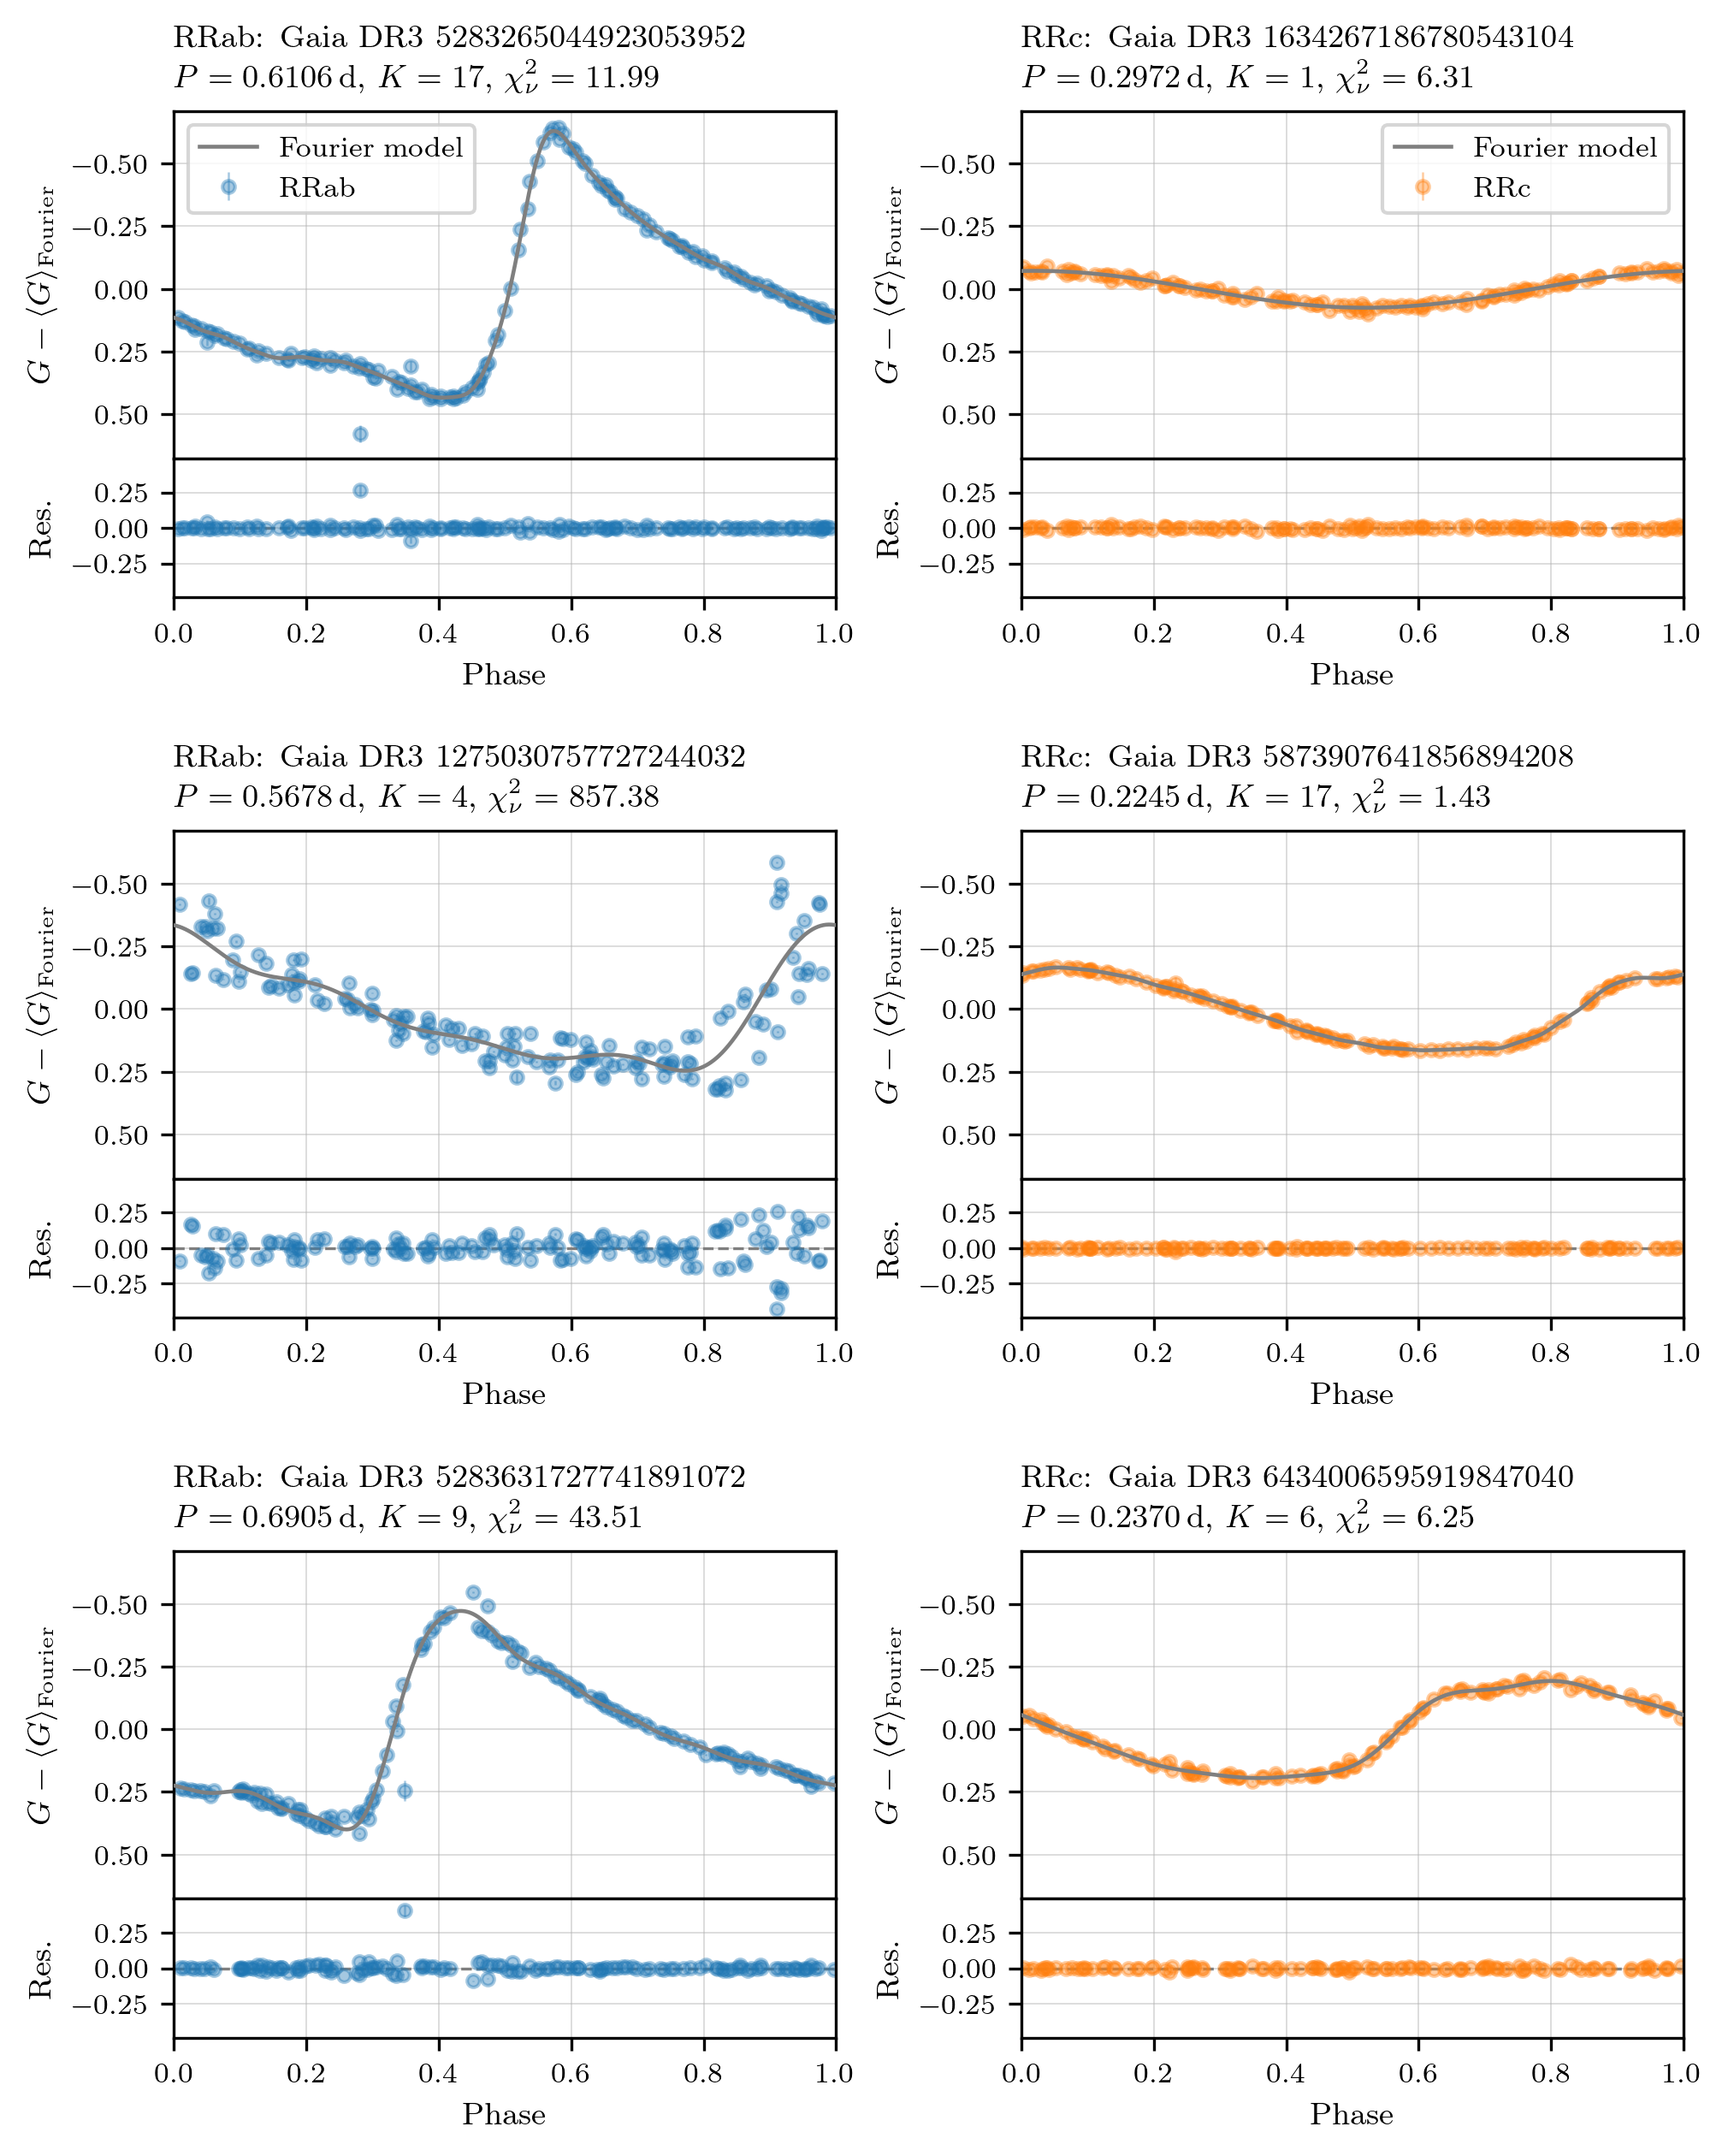

In [6]:
axes = plot_rrlyrae_shape_comparison(rrab, rrc, save=True)
plt.show()

## Analysis and Discussion

The six phased light curves recover the standard class-dependent RR Lyrae morphology very clearly. The **RRab** stars are the more asymmetric objects: they show the familiar steep rise to maximum light, slower decline, and larger peak-to-peak amplitudes. The **RRc** stars are smoother and closer to sinusoidal, with smaller amplitudes and more symmetric light-curve shapes. That contrast has a direct astrophysical origin. RRab stars pulsate in the **radial fundamental mode**, whose light curves are typically more sawtooth-like and therefore require richer harmonic structure. RRc stars pulsate in the **radial first overtone**, which usually produces lower-amplitude and more sinusoidal variability.

A single period plus a finite Fourier series is therefore a good **first-order descriptive model** for all six stars. The fitted curves capture the dominant periodicity and the broad RRab-versus-RRc morphology. But the residual panels remind us that there are really two questions being asked at once. One question is whether the mean light-curve shape is reproduced. The other is whether the star is consistent with a **strictly repeating one-period oscillator** plus measurement noise.

The plot addresses the second question with one explicit goodness-of-fit diagnostic in the panel titles: the reduced $\chi_\nu^2$. That is a standard statistical diagnostic, but its interpretation here should remain modest. If $\chi_\nu^2$ is close to 1, then the observed scatter is broadly consistent with the epoch-level Gaia errors and the finite Fourier truncation. If it is substantially larger than 1, then the mismatch is larger than the nominal measurement noise, which means the limitation lies in the model, the adopted period, or the astrophysics of the star rather than in the plotted $G$-band error bars themselves.

That matters because the epoch-level Gaia photometric errors can be **very small** for these bright stars. Small error bars are therefore expected, not pathological. But that also means that any residual width persisting well beyond those bars is more informative: it becomes evidence that a fixed one-period Fourier template is incomplete. Since the current plots now show only the epoch-level magnitude errors, any visibly broad phase-folded locus should be interpreted as a mismatch between the data and a strictly repeating one-period model, rather than as something the plotted error bars were already designed to absorb.

This is exactly the kind of behavior one expects from stars that deviate from simple strict periodicity. Netzel et al. (2018) describe the **Blazhko effect** in RRc stars as a quasi-periodic modulation of pulsation amplitude and/or phase. In the frequency domain that modulation produces close side peaks and multiplets around the main pulsation frequency and its harmonics; in the time domain it broadens the folded light curve because measurements from different cycles no longer land on exactly the same one-dimensional curve.

That astrophysical interpretation must still be stated carefully. If one or more RRc panels shows $\chi_\nu^2 \gg 1$ or coherent phase-dependent residual structure, then it is reasonable to say that the star is **compatible with** amplitude or phase modulation. But these plots do **not** prove Blazhko modulation in the strict OGLE sense used by Netzel et al. (2018), because the notebook does not search for resolved side peaks or model explicit time dependence in the pulsation amplitude and phase. For RRab stars, any analogous interpretation should be tied to the broader Blazhko literature rather than to Netzel et al. directly, since that paper specifically targets RRc stars.

The most defensible conclusion is therefore that the six stars are **approximately**, but not always **perfectly**, described by a single period. The Fourier models summarize the mean pulsation shape well, yet stars with super-unity $\chi_\nu^2$ or structured residuals are signaling that a strictly periodic one-period model is incomplete. The origin could be amplitude/phase modulation, sparse cadence interacting with a slightly imperfect adopted period, or finite-order model mismatch. Because the formal Gaia uncertainties here are small, residual broadening beyond those error bars should be taken seriously as a model-mismatch diagnostic rather than dismissed as ordinary measurement noise.

References: Clementini et al. 2023, *A\&A*, **674**, A18; Netzel et al. 2018, *MNRAS*, **480**, 1229; Buchler & Kolláth 2011, *ApJ*, **731**, 24.

In the current six-panel figure, the direct notebook result is that all six stars are described reasonably well at the level of their **mean phased shape**, but the single-period Fourier model is not exact for all of them. The RRab examples are the cleanest cases: their folded loci stay close to the fitted template and the residuals are comparatively compact. The RRc examples are less clean. Their residual panels are broader and show more coherent phase-dependent structure, so the notebook evidence points to a model that is adequate as a first-order periodic description but visibly incomplete for at least part of the sample. The right conclusion is therefore not "single-period or nothing"; it is that one period plus a finite Fourier series captures the dominant RR Lyrae morphology while leaving residual structure that is plausibly associated with modulation or additional variability.
